In [78]:
import math
import warnings
from typing import Tuple, Any, Dict

from scipy.constants import e, k, hbar

import jax
from jax import numpy as jnp
from jaxtyping import Array, Scalar

from dynamiqs.options import Options
from dynamiqs.method import Tsit5

from matplotlib import pyplot as plt
from matplotlib import colors as mpc

from blueprint.systems import Fluxonium
from blueprint.drives.pulses import get_cos_pulse
from blueprint.branches.floquet import get_branches
from blueprint.branches.floquet_markov import (
    get_detunings,
    get_matrix_elements,
    get_transition_rates,
)

In [2]:
def get_figsize(
    columns: int = 1,
    fig_width: float | None = None,
    fig_height: float | None = None,
    width_scale: float = 1.0,
    height_scale: float = 1.0,
) -> Tuple[float, float]:
    """
    get_figsize Returns the figure size for a matplotlib plot that is
    consistent with the IEEE journal template.

    Parameters
    ----------
    columns : int, optional
        The number of text columns that the figure takes up, by default 1
    fig_width : float | None, optional
        The width of the figure in inches, by default None
    fig_height : float | None, optional
        The height of the figure in inches, by default None
    width_scale : float, optional
        A scale factor for the width of the figure, by default 1.0
    height_scale : float, optional
        A scale factor for the height of the figure, by default 1.0

    Returns
    -------
    Tuple[float, float]
        The width and height of the figure in inches.

    Raises
    ------
    ValueError
        If the number of columns is not 1 or 2.
    """

    # code adapted from http://www.scipy.org/Cookbook/Matplotlib/LaTeX_Examples

    # Width and max height in inches for IEEE journals taken from
    # computer.org/cms/Computer.org/Journal%20templates/transactions_art_guide.pdf

    if columns not in [1, 2]:
        raise ValueError("Plotting in three-column style is not supported")

    max_height = 8.0
    golden_ratio = 0.5 * (1 + math.sqrt(5))

    if not fig_width:
        fig_width = 3.4 if columns == 1 else 7
    # one-column width is ~8.6cm, double-column is ~17.8cm

    fig_height = fig_height or fig_width / golden_ratio  # height in inches

    if fig_height > max_height:
        warnings.warn(
            f"Figure height {fig_height} is too large, setting to {max_height}"
            "inches instead"
        )

    width = fig_width * width_scale
    height = fig_height * height_scale
    figsize = (width, height)
    return figsize


def get_rc_params(**kwargs: Any) -> Dict[str, Any]:
    """
    get_rc_params Returns the matplotlib rcParams for a plot that is consistent with the IEEE journal template.

    Parameters
    ----------
    **kwargs : Any
        Additional keyword arguments to pass to the rcParams. These will override the default values.
        The arguments that have pre-defined values are:
        - "axes.labelsize": 8
        - "axes.titlesize": 8
        - "legend.fontsize": 8
        - "xtick.labelsize": 8
        - "ytick.labelsize": 8
        - "text.usetex": False
        - "font.family": "serif"

    Returns
    -------
    Dict[str, Any]
        The dictionary of rcParams for the plot.
    """
    # code adapted from http://www.scipy.org/Cookbook/Matplotlib/LaTeX_Examples

    # Width and max height in inches for IEEE journals taken from
    # computer.org/cms/Computer.org/Journal%20templates/transactions_art_guide.pdf
    params = {
        # "backend": "ps", # Commented out because of backened issues
        "axes.labelsize": 8,
        "axes.titlesize": 8,
        "legend.fontsize": 8,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "text.usetex": False,  # This should ideally be True, but leads to issues in certain cases.
        "font.family": "serif",
    }
    params.update(kwargs)
    return params

In [ ]:
type Float = float | Scalar


# Convenience function to avoid creating a full resonator
def get_res_charge_zpf(frequency: Float, impedance: Float) -> Float:
    capacitance = 1 / (impedance * frequency)

    redifined_e = e / math.sqrt(hbar)
    charging_energy = (redifined_e**2) / (2 * capacitance)

    inductance = impedance / frequency
    inductive_energy = 1 / (4 * (redifined_e**2) * inductance)

    charge_zpf = (inductive_energy / (32 * charging_energy)) ** 0.25

    return charge_zpf


In [4]:
USE_DOUBLE_PRECISION: bool = True
USE_GPU: bool = False
DEVICE_IND: int = 0

if USE_DOUBLE_PRECISION:
    jax.config.update("jax_enable_x64", True)  # Double precision

if USE_GPU:
    cuda_devices = jax.devices("cuda")
    if not cuda_devices:
        raise ValueError("No GPU devices found.")

    device = cuda_devices[DEVICE_IND]
    jax.config.update("jax_default_device", device)

In [20]:
# units
GHZ = 2 * math.pi
MHZ = 2e-3 * math.pi
HZ = 2e-9 * math.pi

NS = 1.0
FLUX_QUANTUM = 2 * math.pi

In [6]:
def get_mutual_inductance(
    res_frequency: Float,
    res_impedance: Float,
    res_decay_rate: Float,
    line_impedance: Float,
) -> Scalar:
    numerator = jnp.pi * res_impedance * line_impedance * res_decay_rate
    denominator = 2 * (res_frequency**3)
    mutual_inductance = jnp.sqrt(numerator / denominator)
    return mutual_inductance


def get_load_impedance(
    frequency: Array,
    res_frequency: Float,
    res_impedance: Float,
    res_decay_rate: Float,
    line_impedance: Float,
    ind_scaling: Float = 1.0,
) -> Scalar:
    mutual_ind = get_mutual_inductance(
        res_frequency, res_impedance, res_decay_rate, line_impedance
    )
    self_ind = ind_scaling * mutual_ind
    ind_impedance = 1j * frequency * self_ind
    denominator = 2 * line_impedance + ind_impedance
    mutual_impedance = (frequency * mutual_ind) ** 2 / denominator
    load_impedance = ind_impedance + mutual_impedance
    return load_impedance


def get_input_impedance(
    frequency: Array,
    res_frequency: Float,
    res_impedance: Float,
    res_decay_rate: Float,
    line_impedance: Float,
    ind_scaling: Float = 1.0,
) -> Scalar:
    frequency = 2 * jnp.pi * frequency / HZ
    res_frequency = 2 * jnp.pi * res_frequency / HZ
    res_decay_rate = 2 * jnp.pi * res_decay_rate / HZ

    load_impedance = get_load_impedance(
        frequency,
        res_frequency,
        res_impedance,
        res_decay_rate,
        line_impedance,
        ind_scaling,
    )
    tan_term = jnp.tan(0.5 * jnp.pi * frequency / res_frequency)
    voltage_response = load_impedance + 1j * res_impedance * tan_term
    current_response = res_impedance + 1j * load_impedance * tan_term
    input_impedance = res_impedance * voltage_response / current_response
    return input_impedance


def get_coupling_impedance(
    frequency: Array,
    coupling_strength: Float,
    charging_energy: Float,
    res_frequency: Float,
    res_impedance: Float,
) -> Array:
    coupling_strength = 2 * math.pi * coupling_strength / HZ
    frequency = 2 * math.pi * frequency / HZ

    charging_energy = 2 * math.pi * charging_energy / HZ
    res_frequency = 2 * math.pi * res_frequency / HZ

    qubit_capacitance = 0.5 * (e**2) / (hbar * charging_energy)
    res_capacitance = 1 / (res_impedance * res_frequency)

    coupling_capacitance = (
        hbar * coupling_strength * qubit_capacitance * res_capacitance / (4 * e**2)
    )

    freq_div = jnp.isclose(frequency, 0.0)
    coupling_impedance = jnp.where(
        freq_div, 0.0, 1 / (1j * frequency * coupling_capacitance)
    )
    return coupling_impedance


def get_spectral_density(
    frequency: Array,
    charging_energy: Float,
    impedance: Float,
) -> Array:
    frequency = 2 * math.pi * frequency / HZ
    charging_energy = 2 * jnp.pi * charging_energy / HZ
    capacitance = 0.5 * (e**2) / (hbar * charging_energy)

    real_admittance = jnp.real(1 / impedance)
    freq_div = jnp.isclose(frequency, 0.0)
    _frequency = jnp.where(freq_div, 1.0, frequency)

    numerator = 16 * charging_energy * real_admittance
    denominator = capacitance * jnp.abs(_frequency)
    # Avoid division by zero
    spectral_density = jnp.where(freq_div, 0.0, numerator / denominator)
    spectral_density = spectral_density * HZ / (2 * math.pi)
    return spectral_density


def get_thermal_population(frequency: Array, temperature: Float) -> Array:
    # This is some JAX chicanary to avoid division by zero
    # See https://github.com/jax-ml/jax/issues/1052
    frequency = 2 * math.pi * frequency / HZ

    freq_div = jnp.isclose(frequency, 0.0)
    temp_div = jnp.isclose(temperature, 0.0)

    _temperature = jnp.where(temp_div, 1.0, temperature)
    _frequency = jnp.where(freq_div, 1.0, frequency)

    boltzmann_factor = jnp.exp(hbar * _frequency / (k * _temperature))
    thermal_population = jnp.where(temp_div | freq_div, 0.0, 1 / (boltzmann_factor - 1))
    return thermal_population

In [7]:
FLUXONIUM_LABEL: str = "fluxonium"
JOSEPHSON_ENERGY: float = 4.0 * GHZ
CHARGING_ENERGY: float = 1.0 * GHZ
INDUCTIVE_ENERGY: float = 1.0 * GHZ
EXT_FLUX: float = 0.5 * 2 * math.pi
HARMONIC_CUTOFF: int = 1000
FLUXONIUM_DIM: int = 30

In [8]:
RES_FREQUENCY: float = 7.5 * GHZ
RES_IMPEDANCE: float = 50.0
RES_DECAY_RATE: float = 2.305 * MHZ
RES_DIM: int = 200

In [9]:
COUPLING_STRENGTH: float = 37.444113664685105 * MHZ
# This corresponds to a coupling strength of 120 MHz when multiplied by the charge ZPF of the resonator at the given parameters.

In [10]:
MIN_NUM_PHOTONS: int = 0
MAX_NUM_PHOTONS: int = 200
NUM_PHOTONS: int = 400

DRIVE_PHASE: float = 0.0
DRIVE_FREQ: float = 7.502 * GHZ
DRIVE_PERIOD = 2 * math.pi / DRIVE_FREQ

In [11]:
TEMPERATURE: float = 50e-3  # Kelvin
LINE_IMPEDANCE: float = 50.0  # Ohms
IND_SCALING: float = 1.0
NUM_TIMES: int = 200
NUM_DRIVE_PHOTONS: int = 4

In [12]:
METHOD = Tsit5(rtol=1e-8, atol=1e-8, max_steps=1000000)
OPTIONS = Options(progress_meter=True)

In [13]:
MIN_FREQUENCY = 0.0 * GHZ
MAX_FREQUENCY = 40.0 * GHZ
NUM_FREQUENCIES = 1001

frequencies = jnp.linspace(MIN_FREQUENCY, MAX_FREQUENCY, NUM_FREQUENCIES)

In [ ]:
input_impedance = get_input_impedance(
    frequencies,
    RES_FREQUENCY,
    RES_IMPEDANCE,
    RES_DECAY_RATE,
    LINE_IMPEDANCE,
    IND_SCALING,
)

coupling_impedance = get_coupling_impedance(
    frequencies, COUPLING_STRENGTH, CHARGING_ENERGY, RES_FREQUENCY, RES_IMPEDANCE
)

qubit_impedance = input_impedance + coupling_impedance

spectral_densities = get_spectral_density(
    jnp.abs(frequencies), CHARGING_ENERGY, qubit_impedance
)

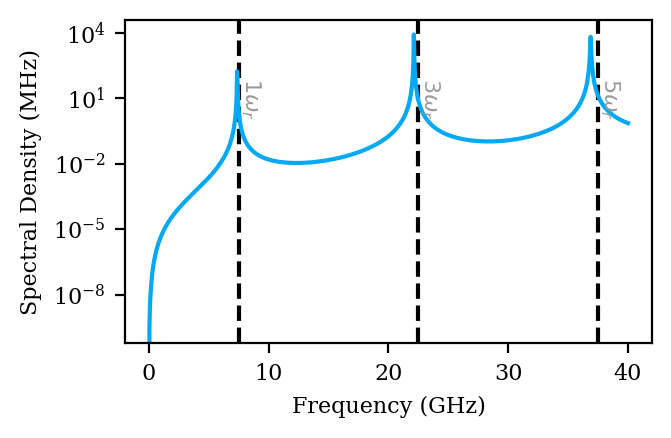

In [15]:
figsize = get_figsize()
rc_params = get_rc_params()

LABEL_DENSITY = 10
FREQ_MULTIPLES = (1, 3, 5)
# Plot the first few odd multiples of the resonator frequency

with plt.rc_context(rc_params):
    fig, ax = plt.subplots(figsize=figsize, dpi=200)

    for freq_mult in FREQ_MULTIPLES:
        frequency = freq_mult * RES_FREQUENCY
        ax.axvline(frequency / GHZ, color="#000000", linestyle="--")

        ax.text(
            frequency / GHZ,
            LABEL_DENSITY,
            f"${freq_mult}\\omega_{{r}}$",
            horizontalalignment="left",
            verticalalignment="center",
            color="#9B9B9B",
            fontsize=8,
            rotation=270,
        )

    ax.plot(
        frequencies / GHZ,
        spectral_densities / MHZ,
        color="#03a9f4",
    )

    ax.set_yscale("log")
    ax.set_xlabel("Frequency (GHz)")
    ax.set_ylabel("Spectral Density (MHz)")
plt.show()

# Perform the Floquet-Markov branch analysis

In [16]:
fluxonium = Fluxonium(
    label=FLUXONIUM_LABEL,
    josephson_energy=JOSEPHSON_ENERGY,
    charging_energy=CHARGING_ENERGY,
    inductive_energy=INDUCTIVE_ENERGY,
    ext_flux=EXT_FLUX,
    harmonic_cutoff=HARMONIC_CUTOFF,
    dim=FLUXONIUM_DIM,
)

hamiltonian = fluxonium.get_hamiltonian()
hamiltonian = hamiltonian.astype(complex)

photons = jnp.linspace(MIN_NUM_PHOTONS, MAX_NUM_PHOTONS + 1, NUM_PHOTONS)

res_charge_zpf = get_res_charge_zpf(RES_FREQUENCY, RES_IMPEDANCE)
drive_amplitudes = 2 * COUPLING_STRENGTH * res_charge_zpf * jnp.sqrt(photons)

drive_op = fluxonium.get_charge_op()
drive_pulse = get_cos_pulse(drive_amplitudes, DRIVE_FREQ, DRIVE_PHASE)

times = jnp.linspace(0, DRIVE_PERIOD, NUM_TIMES)
drive_photons = jnp.arange(-NUM_DRIVE_PHOTONS, NUM_DRIVE_PHOTONS + 1)

quasienergies, modes = get_branches(
    hamiltonian=hamiltonian,
    drive_pulse=drive_pulse,
    drive_op=drive_op,
    drive_period=DRIVE_PERIOD,
    time=times,
    method=METHOD,
    options=OPTIONS,
)

detunings = get_detunings(quasienergies, drive_photons, DRIVE_FREQ)
matrix_elements = get_matrix_elements(modes, times, drive_op, DRIVE_FREQ, drive_photons)

abs_detunings = jnp.abs(detunings)

input_impedance = get_input_impedance(
    detunings,
    RES_FREQUENCY,
    RES_IMPEDANCE,
    RES_DECAY_RATE,
    LINE_IMPEDANCE,
    IND_SCALING,
)

coupling_impedance = get_coupling_impedance(
    detunings,
    COUPLING_STRENGTH,
    CHARGING_ENERGY,
    RES_FREQUENCY,
    RES_IMPEDANCE,
)

impedance = input_impedance + coupling_impedance

spectral_densities = get_spectral_density(abs_detunings, CHARGING_ENERGY, impedance)
thermal_population = get_thermal_population(abs_detunings, TEMPERATURE)

transition_rates = get_transition_rates(
    frequencies=detunings,
    matrix_elements=matrix_elements,
    spectral_density=spectral_densities,
    thermal_population=thermal_population,
)

branches = jnp.take(modes, 0, axis=1)

number_op = fluxonium.get_number_op()
fluxonium_populations = jnp.real(
    jnp.einsum("bia, ij, bja -> ba", jnp.conj(branches), number_op, branches)
)

modular_quasienergies = quasienergies % DRIVE_FREQ

|██████████| 100.0% ◆ elapsed 6.95s ◆ remaining 0.00ms  


In [17]:
COMP_DIM = 2

comp_inds = jnp.arange(COMP_DIM)
leak_inds = jnp.arange(COMP_DIM, FLUXONIUM_DIM)

in_inds, out_inds = jnp.meshgrid(comp_inds, leak_inds, indexing="ij")
leak_rates = jnp.sum(transition_rates[:, in_inds, out_inds], -1)

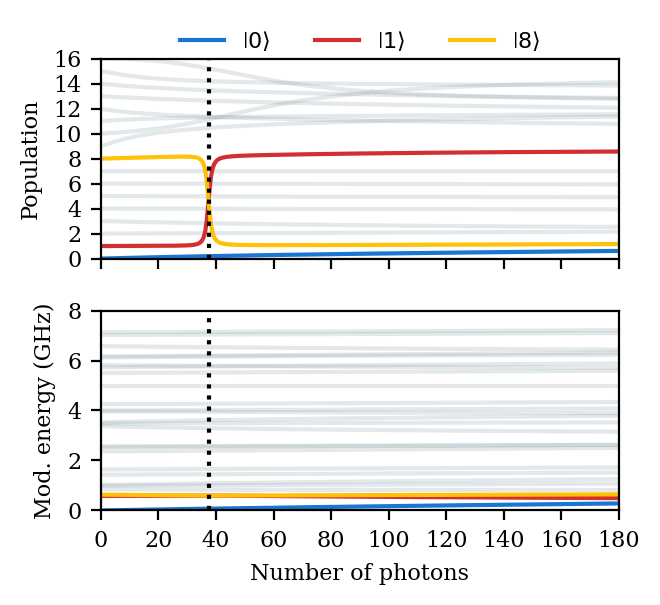

In [ ]:
# Use the recommended figure size for two-column figures
figsize = get_figsize(height_scale=1.5)
rc_params = get_rc_params()  # Use the recommended rc params

highlighted_states = (0, 1, 8)
colors = ["#1976d2", "#d32f2f", "#ffc107"]
default_color = "#90a4ae"

resonance_population = 37.5
num_states = 25  # How many states to plot
states = tuple(range(num_states + 1))
background_states = (state for state in states if state not in highlighted_states)

with plt.rc_context(rc_params):
    fig, axs = plt.subplots(
        nrows=2, sharex=True, figsize=figsize, tight_layout=True, dpi=200
    )
    population_ax, energy_ax = axs

    for state in background_states:
        population_ax.plot(
            photons, fluxonium_populations[:, state], color=default_color, alpha=0.25
        )
        energy_ax.plot(
            photons,
            modular_quasienergies[:, state] / GHZ,
            color=default_color,
            alpha=0.25,
        )

    for state in highlighted_states:
        state_ind = highlighted_states.index(state)
        color = colors[state_ind]
        label = f"$\\left\\vert {{{state}}} \\right\\rangle$"

        population_ax.plot(
            photons, fluxonium_populations[:, state], color=color, label=label
        )
        energy_ax.plot(
            photons, modular_quasienergies[:, state] / GHZ, color=color, label=label
        )

    population_ax.axvline(resonance_population, color="black", linestyle=":")
    energy_ax.axvline(resonance_population, color="black", linestyle=":")

    population_ax.legend(
        ncols=5, frameon=False, loc="upper center", bbox_to_anchor=(0.5, 1.25)
    )

    population_ax.set_ylim(0, 16)
    population_ax.set_yticks([0, 2, 4, 6, 8, 10, 12, 14, 16])
    population_ax.set_ylabel(r"Population")

    energy_ax.set_ylim(0, 8)
    energy_ax.set_yticks([0, 2, 4, 6, 8])
    energy_ax.set_ylabel(r"Mod. energy (GHz)")

    energy_ax.set_xlim(0, 180)
    energy_ax.set_xticks([0, 20, 40, 60, 80, 100, 120, 140, 160, 180])
    energy_ax.set_xlabel(r"Number of photons")

plt.show()

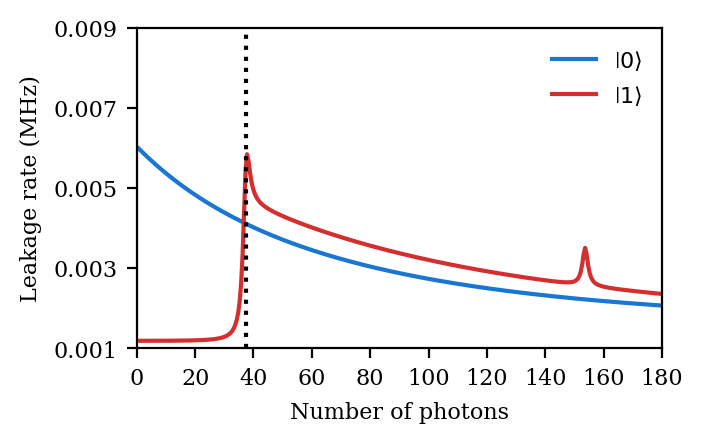

In [ ]:
# Use the recommended figure size for two-column figures
figsize = get_figsize()
rc_params = get_rc_params()  # Use the recommended rc params

comp_states = (0, 1)
comp_colors = ["#1976d2", "#d32f2f"]

resonance_population = 37.5

with plt.rc_context(rc_params):
    fig, ax = plt.subplots(figsize=figsize, constrained_layout=True, dpi=200)

    for state in comp_states:
        state_ind = comp_states.index(state)
        color = comp_colors[state_ind]
        label = f"$\\left\\vert {{{state}}} \\right\\rangle$"

        leak_rate = leak_rates[:, state]
        ax.plot(photons, leak_rate / MHZ, color=color, label=label)

    ax.axvline(resonance_population, color="black", linestyle=":")

    ax.legend(frameon=False)

    ax.set_xlim(0, 180)
    ax.set_xticks([0, 20, 40, 60, 80, 100, 120, 140, 160, 180])
    ax.set_xlabel(r"Number of photons")

    ax.set_ylim(0.001, 0.009)
    ax.set_yticks([0.001, 0.003, 0.005, 0.007, 0.009])
    ax.set_ylabel("Leakage rate (MHz)")

plt.show()

In [21]:
MIN_EXT_FLUX: float = 0.0 * FLUX_QUANTUM
MAX_EXT_FLUX: float = 0.5 * FLUX_QUANTUM
NUM_FLUXES: int = 200

external_fluxes = jnp.linspace(MIN_EXT_FLUX, MAX_EXT_FLUX, NUM_FLUXES)

In [ ]:
def map_function(ext_flux: Float) -> Tuple[Array, Array, Array]:
    fluxonium = Fluxonium(
        label=FLUXONIUM_LABEL,
        josephson_energy=JOSEPHSON_ENERGY,
        charging_energy=CHARGING_ENERGY,
        inductive_energy=INDUCTIVE_ENERGY,
        ext_flux=ext_flux,
        harmonic_cutoff=HARMONIC_CUTOFF,
        dim=FLUXONIUM_DIM,
    )

    hamiltonian = fluxonium.get_hamiltonian()
    hamiltonian = hamiltonian.astype(complex)

    photons = jnp.linspace(MIN_NUM_PHOTONS, MAX_NUM_PHOTONS + 1, NUM_PHOTONS)

    res_charge_zpf = get_res_charge_zpf(RES_FREQUENCY, RES_IMPEDANCE)
    drive_amplitudes = 2 * COUPLING_STRENGTH * res_charge_zpf * jnp.sqrt(photons)

    drive_op = fluxonium.get_charge_op()
    drive_pulse = get_cos_pulse(drive_amplitudes, DRIVE_FREQ, DRIVE_PHASE)

    times = jnp.linspace(0, DRIVE_PERIOD, NUM_TIMES)
    drive_photons = jnp.arange(-NUM_DRIVE_PHOTONS, NUM_DRIVE_PHOTONS + 1)

    quasienergies, modes = get_branches(
        hamiltonian=hamiltonian,
        drive_pulse=drive_pulse,
        drive_op=drive_op,
        drive_period=DRIVE_PERIOD,
        time=times,
        method=METHOD,
        options=OPTIONS,
    )

    detunings = get_detunings(quasienergies, drive_photons, DRIVE_FREQ)
    matrix_elements = get_matrix_elements(
        modes, times, drive_op, DRIVE_FREQ, drive_photons
    )

    abs_detunings = jnp.abs(detunings)

    input_impedance = get_input_impedance(
        detunings,
        RES_FREQUENCY,
        RES_IMPEDANCE,
        RES_DECAY_RATE,
        LINE_IMPEDANCE,
        IND_SCALING,
    )

    coupling_impedance = get_coupling_impedance(
        detunings,
        COUPLING_STRENGTH,
        CHARGING_ENERGY,
        RES_FREQUENCY,
        RES_IMPEDANCE,
    )

    impedance = input_impedance + coupling_impedance

    spectral_densities = get_spectral_density(abs_detunings, CHARGING_ENERGY, impedance)
    thermal_population = get_thermal_population(abs_detunings, TEMPERATURE)

    transition_rates = get_transition_rates(
        frequencies=detunings,
        matrix_elements=matrix_elements,
        spectral_density=spectral_densities,
        thermal_population=thermal_population,
    )

    branches = jnp.take(modes, 0, axis=1)
    return quasienergies, branches, transition_rates


quasienergies, branches, transition_rates = jax.block_until_ready(
    jax.lax.map(map_function, external_fluxes)
)

|██████████| 100.0% ◆ elapsed 8.20s ◆ remaining 0.00ms   
|██████████| 100.0% ◆ elapsed 9.34s ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 8.89s ◆ remaining 0.00ms   
|██████████| 100.0% ◆ elapsed 8.11s ◆ remaining 0.00ms   
|██████████| 100.0% ◆ elapsed 8.49s ◆ remaining 0.00ms   
|██████████| 100.0% ◆ elapsed 8.20s ◆ remaining 0.00ms   
|██████████| 100.0% ◆ elapsed 8.10s ◆ remaining 0.00ms   
|██████████| 100.0% ◆ elapsed 8.05s ◆ remaining 0.00ms   
|██████████| 100.0% ◆ elapsed 8.34s ◆ remaining 0.00ms   
|██████████| 100.0% ◆ elapsed 9.13s ◆ remaining 0.00ms   
|██████████| 100.0% ◆ elapsed 8.19s ◆ remaining 0.00ms   
|██████████| 100.0% ◆ elapsed 8.03s ◆ remaining 0.00ms   
|██████████| 100.0% ◆ elapsed 8.89s ◆ remaining 0.00ms   
|██████████| 100.0% ◆ elapsed 8.18s ◆ remaining 0.00ms   
|██████████| 100.0% ◆ elapsed 8.02s ◆ remaining 0.00ms   
|██████████| 100.0% ◆ elapsed 8.05s ◆ remaining 0.00ms   
|██████████| 100.0% ◆ elapsed 8.35s ◆ remaining 0.00ms   
|██████████| 10

In [25]:
number_op = fluxonium.get_number_op()

fluxonium_populations = jnp.real(
    jnp.einsum("bcia, ij, bcja -> bca", jnp.conj(branches), number_op, branches)
)

modular_quasienergies = quasienergies % DRIVE_FREQ

In [26]:
COMP_DIM = 2

comp_inds = jnp.arange(COMP_DIM)
leak_inds = jnp.arange(COMP_DIM, FLUXONIUM_DIM)

in_inds, out_inds = jnp.meshgrid(comp_inds, leak_inds, indexing="ij")
leak_rates = jnp.sum(transition_rates[:, :, in_inds, out_inds], -1)

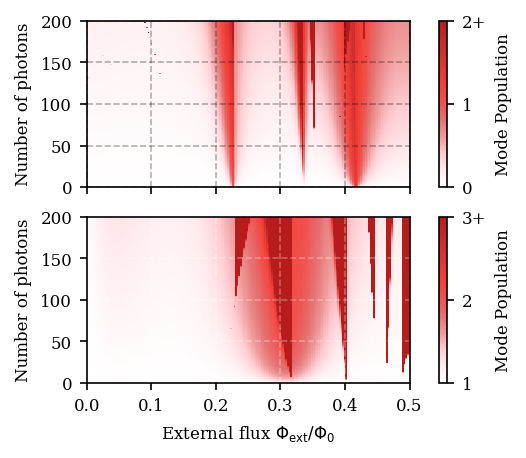

In [98]:
state_inds = (0, 1)

red_colors = [
    "#ffffff",
    "#ffebee",
    "#ffcdd2",
    "#ef9a9a",
    "#e57373",
    "#ef5350",
    "#f44336",
    "#e53935",
    "#d32f2f",
    "#c62828",
    "#b71c1c",
]
red_cmap = mpc.LinearSegmentedColormap.from_list("material_red", red_colors) # type: ignore

flux_grid, photon_grid = jnp.meshgrid(external_fluxes, photons)

figsize = get_figsize(height_scale=1.4)
rc_params = get_rc_params()

with plt.rc_context(rc_params):
    fig, axs = plt.subplots(
        nrows=2, sharex=True, figsize=figsize, constrained_layout=True, dpi=150
    )

    ground_ax, exc_ax = axs

    ground_population = jnp.transpose(fluxonium_populations[:, :, 0])

    img = ground_ax.pcolormesh(
        flux_grid / FLUX_QUANTUM,
        photon_grid,
        ground_population,
        cmap=red_cmap,
        vmin=0,
        vmax=2,
    )

    colorbar = fig.colorbar(img, ax=ground_ax)
    colorbar_ticks = list(range(0, 3))
    colorbar_ticklabels = []
    for tick in colorbar_ticks:
        label = str(tick) if tick < 2 else f"{tick}+"
        colorbar_ticklabels.append(label)
    colorbar.set_ticks(colorbar_ticks)
    colorbar.set_ticklabels(colorbar_ticklabels)
    colorbar.set_label("Mode Population")

    ground_ax.grid(True, linestyle="--", color="#000000", alpha=0.3, zorder=1)

    ground_ax.set_ylim(0, MAX_NUM_PHOTONS)
    ground_ax.set_yticks([0, 50, 100, 150, 200])
    ground_ax.set_ylabel(r"Number of photons")

    excited_population = jnp.transpose(fluxonium_populations[:, :, 1])

    img = exc_ax.pcolormesh(
        flux_grid / FLUX_QUANTUM,
        photon_grid,
        excited_population,
        cmap=red_cmap,
        vmin=1,
        vmax=3,
    )

    colorbar = fig.colorbar(img, ax=exc_ax)
    colorbar_ticks = list(range(1, 4))
    colorbar_ticklabels = []
    for tick in colorbar_ticks:
        label = str(tick) if tick < 3 else f"{tick}+"
        colorbar_ticklabels.append(label)
    colorbar.set_ticks(colorbar_ticks)
    colorbar.set_ticklabels(colorbar_ticklabels)
    colorbar.set_label("Mode Population")

    exc_ax.grid(True, linestyle="--", color="#ffffff", alpha=0.3, zorder=1)

    exc_ax.set_ylim(0, MAX_NUM_PHOTONS)
    exc_ax.set_yticks([0, 50, 100, 150, 200])
    exc_ax.set_ylabel(r"Number of photons")

exc_ax.set_xlim(MIN_EXT_FLUX / FLUX_QUANTUM, MAX_EXT_FLUX / FLUX_QUANTUM)
exc_ax.set_xlabel(r"External flux $\Phi_\mathrm{ext} / \Phi_0$")

plt.show()

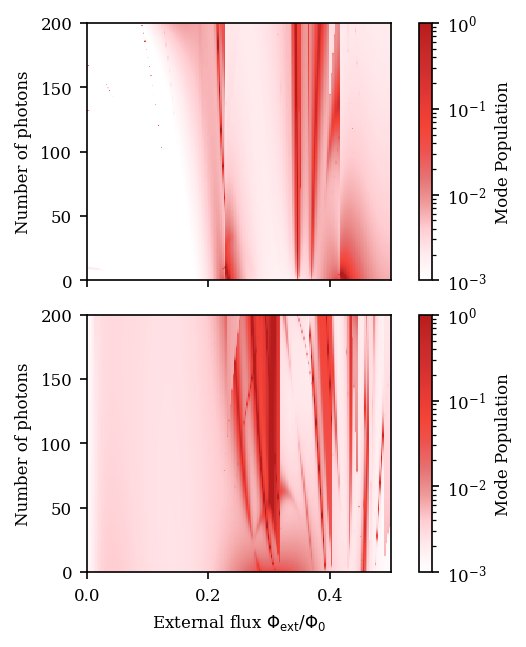

In [97]:
state_inds = (0, 1)

red_colors = [
    "#ffffff",
    "#ffebee",
    "#ffcdd2",
    "#ef9a9a",
    "#e57373",
    "#ef5350",
    "#f44336",
    "#e53935",
    "#d32f2f",
    "#c62828",
    "#b71c1c",
]
red_cmap = mpc.LinearSegmentedColormap.from_list("material_red", red_colors)  # type: ignore

norm = mpc.LogNorm(vmin=1e-3, vmax=1)  # type: ignore

flux_grid, photon_grid = jnp.meshgrid(external_fluxes, photons)

figsize = get_figsize(height_scale=2.0)
rc_params = get_rc_params()

with plt.rc_context(rc_params):
    fig, axs = plt.subplots(
        nrows=2, sharex=True, figsize=figsize, constrained_layout=True, dpi=150
    )

    ground_ax, exc_ax = axs

    ground_rates = jnp.transpose(leak_rates[:, :, 0])

    img = ground_ax.pcolormesh(
        flux_grid / FLUX_QUANTUM,
        photon_grid,
        ground_rates / MHZ,
        cmap=red_cmap,
        norm=norm,
    )

    colorbar = fig.colorbar(img, ax=ground_ax)
    colorbar.set_label("Mode Population")

    ground_ax.set_ylim(0, MAX_NUM_PHOTONS)
    ground_ax.set_yticks([0, 50, 100, 150, 200])
    ground_ax.set_ylabel(r"Number of photons")

    exc_rates = jnp.transpose(leak_rates[:, :, 1])

    img = exc_ax.pcolormesh(
        flux_grid / FLUX_QUANTUM, photon_grid, exc_rates / MHZ, cmap=red_cmap, norm=norm
    )

    colorbar = fig.colorbar(img, ax=exc_ax)
    colorbar.set_label("Mode Population")
    colorbar_ticks = list(range(0, 3))
    colorbar_ticklabels = []
    for tick in colorbar_ticks:
        label = str(tick) if tick < 2 else f"{tick}+"
        colorbar_ticklabels.append(label)

    exc_ax.set_ylim(0, MAX_NUM_PHOTONS)
    exc_ax.set_yticks([0, 50, 100, 150, 200])
    exc_ax.set_ylabel(r"Number of photons")

exc_ax.set_xlim(MIN_EXT_FLUX / FLUX_QUANTUM, MAX_EXT_FLUX / FLUX_QUANTUM)
exc_ax.set_xlabel(r"External flux $\Phi_\mathrm{ext} / \Phi_0$")

plt.show()